In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense
)

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_model(model_type):

    model = Sequential()

    model.add(
        Embedding(
            vocab_size,
            64,
            input_length=maxlen
        )
    )

    if model_type == "RNN":
        model.add(SimpleRNN(64))

    elif model_type == "LSTM":
        model.add(LSTM(64))

    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [4]:
print("\nTraining RNN...\n")

rnn_model = build_model("RNN")

rnn_history = rnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training RNN...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7043 - loss: 0.5417 - val_accuracy: 0.7995 - val_loss: 0.4457
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8652 - loss: 0.3273 - val_accuracy: 0.6704 - val_loss: 0.6079
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8780 - loss: 0.2939 - val_accuracy: 0.7799 - val_loss: 0.4950


In [5]:
print("\nTraining LSTM...\n")

lstm_model = build_model("LSTM")

lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training LSTM...

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7815 - loss: 0.4545 - val_accuracy: 0.8651 - val_loss: 0.3223
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8990 - loss: 0.2502 - val_accuracy: 0.8705 - val_loss: 0.3133
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9329 - loss: 0.1844 - val_accuracy: 0.8697 - val_loss: 0.3373


In [6]:
print("\nTraining GRU...\n")

gru_model = build_model("GRU")

gru_history = gru_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, y_test)
)



Training GRU...

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7682 - loss: 0.4589 - val_accuracy: 0.8558 - val_loss: 0.3370
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8974 - loss: 0.2597 - val_accuracy: 0.8628 - val_loss: 0.3516
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9255 - loss: 0.1951 - val_accuracy: 0.8664 - val_loss: 0.3239


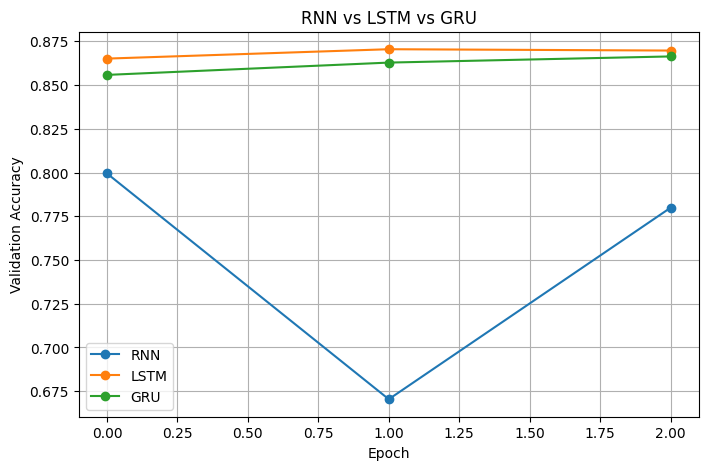

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history['val_accuracy'],
    marker='o',
    label='RNN'
)

plt.plot(
    lstm_history.history['val_accuracy'],
    marker='o',
    label='LSTM'
)

plt.plot(
    gru_history.history['val_accuracy'],
    marker='o',
    label='GRU'
)

plt.title("RNN vs LSTM vs GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()


In [8]:
rnn_acc = max(rnn_history.history['val_accuracy'])
lstm_acc = max(lstm_history.history['val_accuracy'])
gru_acc = max(gru_history.history['val_accuracy'])

print("\nFinal Validation Accuracy")

print(f"RNN  Accuracy : {rnn_acc:.4f}")
print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"GRU  Accuracy : {gru_acc:.4f}")



Final Validation Accuracy
RNN  Accuracy : 0.7995
LSTM Accuracy : 0.8705
GRU  Accuracy : 0.8664


In [9]:
best_accuracy = max(rnn_acc, lstm_acc, gru_acc)

if best_accuracy == lstm_acc:
    best_model = "LSTM"

elif best_accuracy == gru_acc:
    best_model = "GRU"

else:
    best_model = "RNN"

print(f"\nBest Performing Model: {best_model}")


Best Performing Model: LSTM
